In [1]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
print("1. Memuat Data dan Model untuk Visualisasi...")

# Load Data
df = pd.read_csv('./data/processed/data_toren_v2.csv')

fitur_x = [
    'ph', 'tds', 'turbidity', 'temperature',
    'turbidity_MA_3', 'tds_MA_3', 'ph_MA_3',
    'turbidity_Diff', 'tds_Diff', 'ph_Diff',
    'turbidity_Std_3', 'tds_Std_3'
]

# Load Model
model_xgb = joblib.load('models/xgb_model4.pkl')
model_gru = load_model('models/gru_model4.keras')

1. Memuat Data dan Model untuk Visualisasi...


In [4]:
# ==========================================
# 2. MENGHITUNG METRIK UNTUK BAR CHART
# ==========================================
window_size = 10 
y_all = np.clip(df['RUL'].values, a_min=0, a_max=60)
X_all = df[fitur_x].values

def create_sequences(data, target, window):
    X_seq, y_seq = [], []
    for i in range(len(data) - window):
        X_seq.append(data[i:(i + window)])
        y_seq.append(target[i + window])
    return np.array(X_seq), np.array(y_seq)

X_gru, y_gru = create_sequences(X_all, y_all, window_size)
X_xgb = X_all[window_size:]
y_xgb = y_all[window_size:]

print("2. Menghitung Prediksi Keseluruhan...")
pred_xgb = model_xgb.predict(X_xgb)
pred_gru = model_gru.predict(X_gru, verbose=0).flatten()

# Hitung Metrik
mae_xgb = mean_absolute_error(y_xgb, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_xgb, pred_xgb))

mae_gru = mean_absolute_error(y_gru, pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_gru, pred_gru))

2. Menghitung Prediksi Keseluruhan...


In [5]:
# ==========================================
# 3. MENGAMBIL 1 SIKLUS UNTUK LINE CHART
# ==========================================
# Mengambil ID siklus terakhir di dataset untuk simulasi (misal Siklus ke-1000)
siklus_tes = df['Cycle_ID'].unique()[-1]
df_tes = df[df['Cycle_ID'] == siklus_tes].copy()

# Persiapan data spesifik 1 siklus
y_tes_all = np.clip(df_tes['RUL'].values, 0, 60)
X_tes_all = df_tes[fitur_x].values

X_tes_gru, y_tes_gru = create_sequences(X_tes_all, y_tes_all, window_size)
X_tes_xgb = X_tes_all[window_size:]
y_tes_xgb = y_tes_all[window_size:]
hari_tes = df_tes['Hari'].values[window_size:]

print(f"3. Membuat Prediksi Khusus untuk Siklus ID: {siklus_tes}")
pred_tes_xgb = model_xgb.predict(X_tes_xgb)
pred_tes_gru = model_gru.predict(X_tes_gru, verbose=0).flatten()

3. Membuat Prediksi Khusus untuk Siklus ID: 1000


4. Menggambar Grafik Laporan...

SELESAI! Grafik berhasil disimpan sebagai 'evaluasi_model_final.png'.


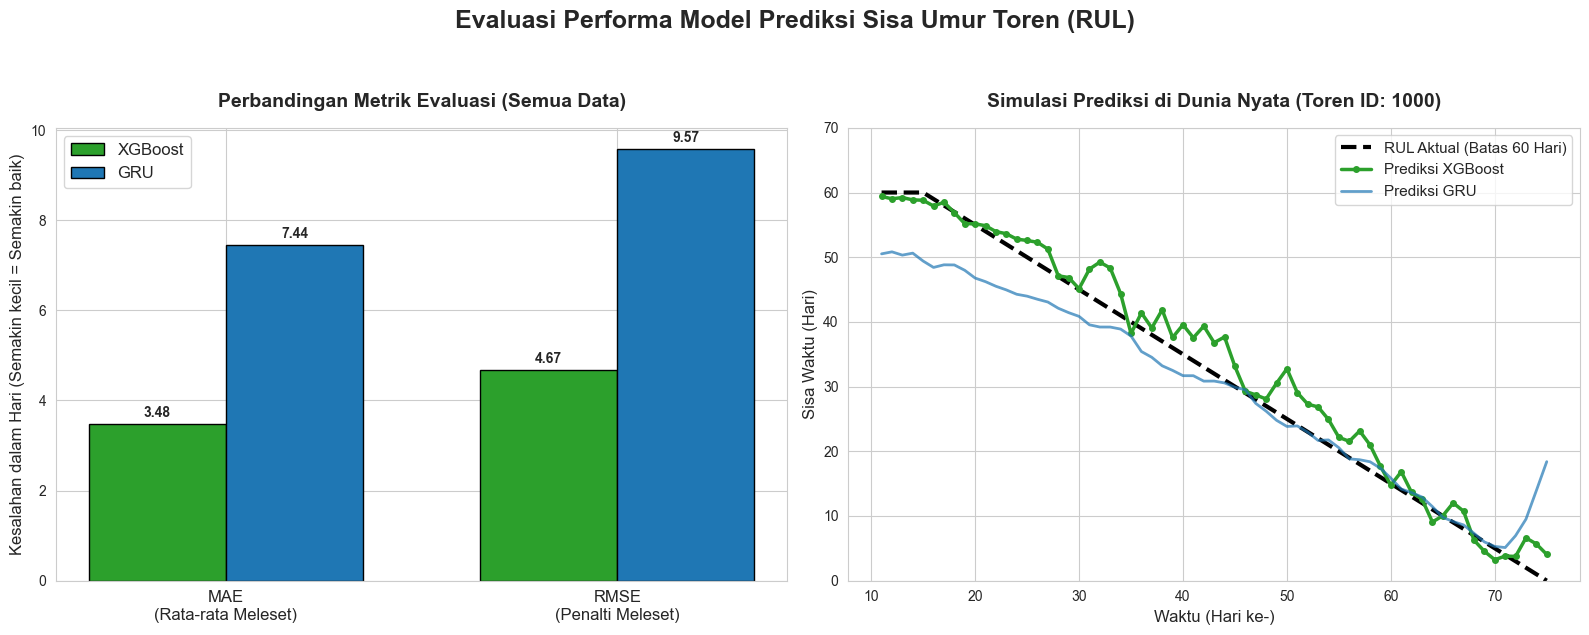

In [6]:
# ==========================================
# 4. MENGGAMBAR VISUALISASI
# ==========================================
print("4. Menggambar Grafik Laporan...")
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evaluasi Performa Model Prediksi Sisa Umur Toren (RUL)', fontsize=18, fontweight='bold', y=1.05)

# --- PANEL KIRI: Bar Chart Metrik ---
labels = ['MAE\n(Rata-rata Meleset)', 'RMSE\n(Penalti Meleset)']
x = np.arange(len(labels))
width = 0.35

bar_xgb = axes[0].bar(x - width/2, [mae_xgb, rmse_xgb], width, label='XGBoost', color='#2ca02c', edgecolor='black')
bar_gru = axes[0].bar(x + width/2, [mae_gru, rmse_gru], width, label='GRU', color='#1f77b4', edgecolor='black')

axes[0].set_ylabel('Kesalahan dalam Hari (Semakin kecil = Semakin baik)', fontsize=12)
axes[0].set_title('Perbandingan Metrik Evaluasi (Semua Data)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].legend(fontsize=12)

# Menambahkan angka di atas batang
for bar in bar_xgb:
    axes[0].annotate(f'{bar.get_height():.2f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
for bar in bar_gru:
    axes[0].annotate(f'{bar.get_height():.2f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

# --- PANEL KANAN: Line Chart Prediksi 1 Siklus ---
axes[1].plot(hari_tes, y_tes_xgb, label='RUL Aktual (Batas 60 Hari)', color='black', linewidth=3, linestyle='--')
axes[1].plot(hari_tes, pred_tes_xgb, label='Prediksi XGBoost', color='#2ca02c', linewidth=2.5, marker='o', markersize=4)
axes[1].plot(hari_tes, pred_tes_gru, label='Prediksi GRU', color='#1f77b4', linewidth=2, alpha=0.7)

axes[1].set_xlabel('Waktu (Hari ke-)', fontsize=12)
axes[1].set_ylabel('Sisa Waktu (Hari)', fontsize=12)
axes[1].set_title(f'Simulasi Prediksi di Dunia Nyata (Toren ID: {siklus_tes})', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(fontsize=11)
axes[1].set_ylim(0, 70)

# Merapikan Tata Letak dan Menyimpan
plt.tight_layout()
nama_file = 'evaluasi_model_final.png'
plt.savefig(nama_file, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\nSELESAI! Grafik berhasil disimpan sebagai '{nama_file}'.")
plt.show()